# Project 2: Customer Segmentation Using K-Means Clustering

## Internship Project

### Objective
The objective of this project is to segment ecommerce customers into different groups based on their online behavior, membership duration, and yearly spending.

The project uses the K-Means Clustering algorithm to identify customer segments that can help businesses understand their customers and create better marketing strategies.

### Dataset
The dataset contains information about 500 ecommerce customers, including:

- Email
- Address
- Avatar
- Time on App
- Time on Website
- Length of Membership
- Yearly Amount Spent

### Tools and Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data.csv")

df.head()

,\tEmail,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,3.12,581.85
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,4.45,599.41


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   	Email                500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Time on App           500 non-null    float64
 4   Time on Website       500 non-null    float64
 5   Length of Membership  500 non-null    float64
 6   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4), str(3)
memory usage: 27.5 KB


In [4]:
df.isnull().sum()

\tEmail                 0
Address                 0
Avatar                  0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.00000,500.000000
mean,12.052620,37.060480,3.53336,499.314240
std,0.994418,1.010555,0.99926,79.314764
min,8.510000,33.910000,0.27000,256.670000
25%,11.390000,36.347500,2.93000,445.037500
50%,11.980000,37.070000,3.53500,498.890000
75%,12.752500,37.720000,4.13000,549.312500
max,15.130000,40.010000,6.92000,765.520000


In [7]:
features = df[
    [
        "Time on App",
        "Time on Website",
        "Length of Membership",
        "Yearly Amount Spent"
    ]
]

features.head()

,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,12.66,39.58,4.08,587.95
1,11.11,37.27,2.66,392.20
2,11.33,37.11,4.10,487.55
3,13.72,36.72,3.12,581.85
4,12.80,37.54,4.45,599.41


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 0.61140116,  2.49570019,  0.54759246,  1.11863825],
       [-0.94886062,  0.20753918, -0.87488173, -1.35184813],
       [-0.72740411,  0.04905183,  0.56762731, -0.148472  ],
       [ 1.67841889, -0.33726107, -0.41408023,  1.04165247],
       [ 0.75232803,  0.47498657,  0.91823714,  1.26327056]])

In [9]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

inertia

[1999.999999999999,
 1408.3881961155898,
 1175.9441656191311,
 1010.4941468442819,
 874.4032989441466,
 790.256899914456,
 722.8241576576809,
 656.5148598896856,
 615.0809519632822,
 579.9347031922032]

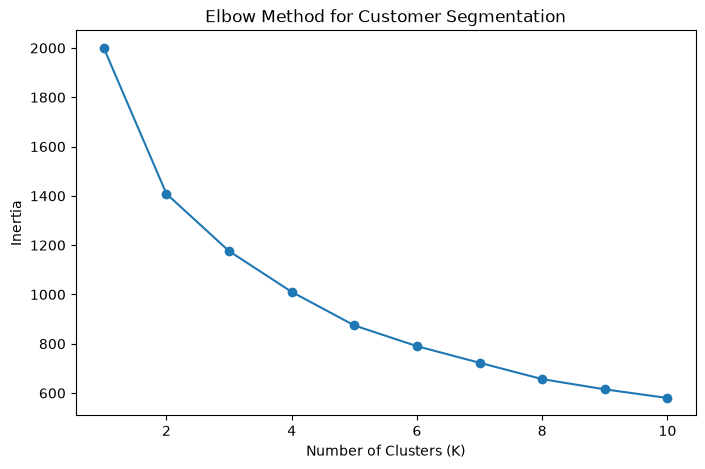

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")

plt.show()


In [11]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_features)

df.head()

,\tEmail,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,Cluster
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95,3
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20,0
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55,2
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,3.12,581.85,1
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,4.45,599.41,1


In [12]:
df["Cluster"].value_counts()

Cluster
2    178
3    114
0    114
1     94
Name: count, dtype: int64

In [13]:
cluster_summary = df.groupby("Cluster")[
    [
        "Time on App",
        "Time on Website",
        "Length of Membership",
        "Yearly Amount Spent"
    ]
].mean()

cluster_summary.round(2)

,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Cluster,,,,
0,11.57,37.07,2.34,401.22
1,12.96,36.96,4.58,606.81
2,11.63,36.42,3.82,500.44
3,12.44,38.13,3.41,507.01


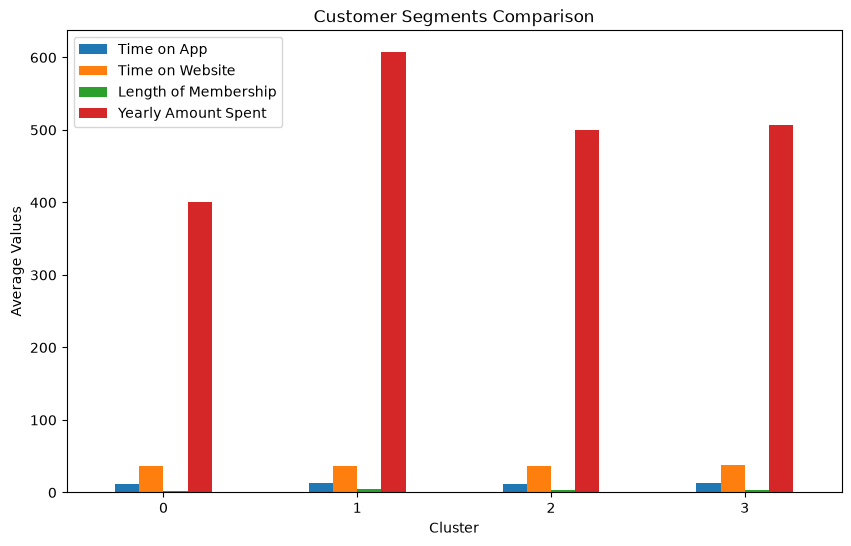

In [14]:
import matplotlib.pyplot as plt

cluster_summary.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Customer Segments Comparison")
plt.xlabel("Cluster")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.legend()
plt.show()

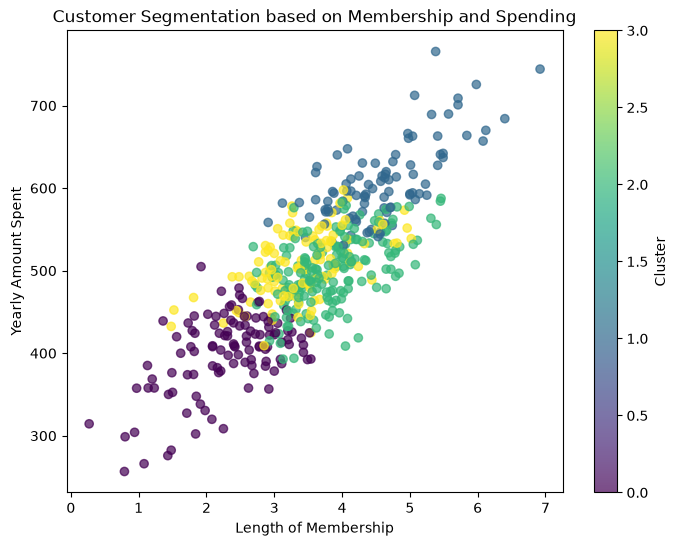

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Length of Membership"],
    df["Yearly Amount Spent"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Length of Membership")
plt.ylabel("Yearly Amount Spent")
plt.title("Customer Segmentation based on Membership and Spending")

plt.colorbar(label="Cluster")
plt.show()

## Conclusion

Customer segmentation was successfully performed using the K-Means clustering algorithm.

The analysis divided 500 customers into 4 different clusters based on their online activity, membership duration, and yearly spending.

- Cluster 0 represents low-value customers with lower spending and shorter membership duration.
- Cluster 1 represents high-value and loyal customers with the highest yearly spending and longer membership duration.
- Cluster 2 represents the largest group of regular customers with moderate spending.
- Cluster 3 represents customers with higher website activity and moderate-to-high spending.

These customer segments can help businesses create targeted marketing strategies and improve customer retention. High-value customers can be given special offers and loyalty rewards, while lower-value customers can be targeted with personalized promotions.